In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
# from kret_studies import *
# from kret_studies.notebook import *
# from kret_studies.complex import *

# logger = get_notebook_logger()

In [3]:
from waymo_agent.notebook_imports import *

In [4]:
from functools import cache

In [5]:
from waymo_agent import *
from waymo_agent.osmnx import *
from waymo_agent.data_classes import *
from waymo_agent.action_heuristic import *
from waymo_agent.graph_env import *
from waymo_agent.simulation import *
from waymo_agent.action_heuristic.heuristic_simple import PricingAgent, DispatchAgent, RepositionAgent

In [6]:
from kret_sandbox.VIS import dtt
from kret_sandbox.exp_decay import exp_decay_half_life

In [7]:
def get_obvs_tuple(env: RideShareEnv):
    veh = env.observation_curr["vehicles"]
    req = env.observation_curr["pending_requests"]
    rides = env.observation_curr["active_rides"]
    return veh, req, rides

# Run Sim

<Axes: title={'center': 'Epsilon Decay with Gamma = 0.99985'}>

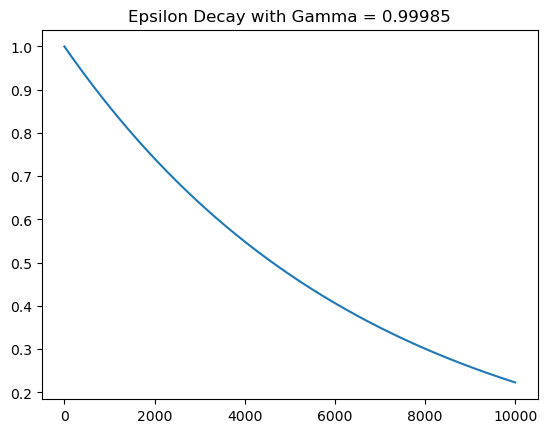

In [15]:
HALF_LIFE = 5000
GAMMA = 0.99985
epsilons = exp_decay_half_life(10_000, gamma=GAMMA)
pd.Series(epsilons).plot(title=f"Epsilon Decay with Gamma = {GAMMA}")

In [19]:
def discounted_rewards(rewards: np.ndarray, gamma: float = 0.997):
    """
    Discount rewards using discount factor gamma.
    """
    disc_schedule = exp_decay_half_life(len(rewards), gamma=gamma)
    return rewards * disc_schedule


def get_act_dict(agents: tuple[PricingAgent, DispatchAgent, RepositionAgent], obs: ObservationDict) -> ActionDict:
    price_agent, dispatch_agent, reposition_agent = agents
    prices = price_agent.price(obs)
    dispatch_actions = dispatch_agent.dispatch(obs)
    reposition_actions = reposition_agent.reposition(obs)

    action_agent: ActionDict = {
        "prices": prices,
        "dispatch": dispatch_actions,
        "reposition": reposition_actions,
    }
    return action_agent

In [ ]:
def run_heuristic_simulation(env_curr: RideShareEnv, num_iter: int = 1):
    REWARDS: list[list[float]] = []
    OBS: list[list[ObservationDict]] = []
    ACT: list[list[ActionDict]] = []

    agents = (PricingAgent(env_curr.config), DispatchAgent(env_curr), RepositionAgent(env_curr))

    tqdm.write("Starting heuristic simulation...")

    for iter_count in tqdm(range(num_iter)):
        rews_raw: list[float] = []
        obs_list: list[ObservationDict] = []
        act_list: list[ActionDict] = []
        done = False
        obs, info = env_curr.reset()

        while not done:
            obs: ObservationDict
            obs_list.append(obs)

            action_agent: ActionDict = get_act_dict(agents, obs)
            act_list.append(action_agent)

            obs, reward, term, done, info = env_curr.step(action_agent)  # type: ignore

            rews_raw.append(reward)
            if term:
                tqdm.write(f"WARNING: Episode terminated at step {env_curr.current_step}")
            done = done or term

        rews = discounted_rewards(np.array(rews_raw), gamma=GAMMA).tolist()
        REWARDS.append(rews)
        OBS.append(obs_list)
        ACT.append(act_list)
    return (REWARDS), OBS, ACT, env_curr, agents

In [25]:
config = EnvConfig(max_episode_steps=60 * 3)
plt_cfg = PlotConfig()

In [26]:
env_heuristic = RideShareEnv(config, plt_cfg)
G = env_heuristic.G
cfg = env_heuristic.config

Assigned lambda values to nodes. Total lambda: 2.2280 (target: 2.3460)


/Users/Akseldkw/micromamba/envs/kret_312/lib/python3.12/site-packages/gymnasium/spaces/box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/Users/Akseldkw/micromamba/envs/kret_312/lib/python3.12/site-packages/gymnasium/spaces/box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


In [27]:
REWARDS, OBS, ACT, env_curr, agents = run_heuristic_simulation(env_heuristic, num_iter=5)

Starting heuristic simulation...


100%|██████████| 5/5 [01:01<00:00, 12.34s/it]


In [ ]:
arr = np.array(REWARDS)
arr.shape

(5, 181)

In [35]:
arr2 = arr.reshape(-1, arr.shape[0])
arr2.shape

(181, 5)

In [36]:
pd.DataFrame(arr2)

,0,1,2,3,4
0,0.000000,0.000000,1.199640,0.135630,0.379301
1,0.233252,-0.157225,-0.122982,-0.591333,-0.706863
2,0.234375,0.420901,0.985467,-0.144414,2.896067
3,-0.217176,1.297572,0.865732,1.496606,0.735964
4,0.182475,1.785050,0.541758,0.998995,2.407283
...,...,...,...,...,...
176,0.475577,3.646878,2.599660,6.503858,2.495791
177,0.694825,0.727968,2.791800,3.835558,1.381809
178,2.385986,4.795629,0.631846,0.620727,0.643207
179,3.284221,0.377831,0.750801,0.018138,2.549395


In [53]:
for key, val in env_heuristic.action_space.items():
    print(key, val, val.dtype, val.shape)
    print("\n")

dispatch MultiDiscrete([25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25
 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25
 25 25], start=[-1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1]) int64 (50,)


prices Box(0.0, inf, (50,), float64) float64 (50,)


reposition Box(-1.0, 1.0, (24, 2), float32) float32 (24, 2)




In [54]:
for key, val in env_heuristic.observation_space.items():
    print(key, val, val.dtype, val.shape)
    print("\n")

active_rides Box(0.0, 1.0, (24, 9), float32) float32 (24, 9)


dispatch_mask Box(0.0, 1.0, (24,), float32) float32 (24,)


globals Box([-1. -1. -1. -1.  0.], [1. 1. 1. 1. 2.], (5,), float32) float32 (5,)


pending_requests Box(0.0, 1.0, (50, 9), float32) float32 (50, 9)


pricing_mask Box(0.0, 1.0, (50,), float32) float32 (50,)


supply_demand_ratio Box(0.0, 1.0, (3,), float32) float32 (3,)


vehicles Box(0.0, 1.0, (24, 4), float32) float32 (24, 4)




In [ ]:
env_curr.observation_space["vehicles"].shape

(24, 4)

In [55]:
pprint(env_curr.config)

EnvConfig(map_name='manhattan-sparse-782-nodes-enriched.graphml',
          map_dir=PosixPath('/Users/Akseldkw/coding/Columbia/RL-Project/maps'),
          vehicle_per_node=0.03,
          max_vehicles=50,
          time_step_delta=datetime.timedelta(seconds=60),
          max_episode_steps=180,
          day_per_week=7,
          hours_per_day=24,
          lambda_per_node=0.003,
          lambda_variation_coef=2.0,
          max_new_requests_per_step=None,
          max_pending_requests=50,
          max_wait_time_minutes=15,
          max_price=inf,
          invalid_id=-1,
          acceptance_margin_weight=-2.0,
          acceptance_supply_demand_weight=3.0,
          battery_consumption_per_km=0.01,
          charge_rate_per_minute=0.12,
          min_battery_for_assignment=0.2,
          chargable_node_ratio=0.01,
          max_chargers_per_node=1,
          penalty_rejected=-1.0,
          penalty_expire=-2.0,
          penalty_overflow=-1.5,
          reward_frac_ride_completi

In [ ]:
# fig, ax = plt.subplots(1, 2, figsize=(12, 6))
# pd.Series(rews).cumsum().plot(title="Cumulative Reward over Time - Heuristic Agents", ax=ax[0])
# ax[0].set_xlabel("Time Step")
# ax[0].set_ylabel("Cumulative Reward")
# ax[0].grid()
# plt.show()

In [22]:
# env.breadcrumbs["rewards"].cumsum().plot(title="Cumulative Reward over Time")
# plt.xlabel("Time Step")
# plt.ylabel("Cumulative Reward")
# plt.show()

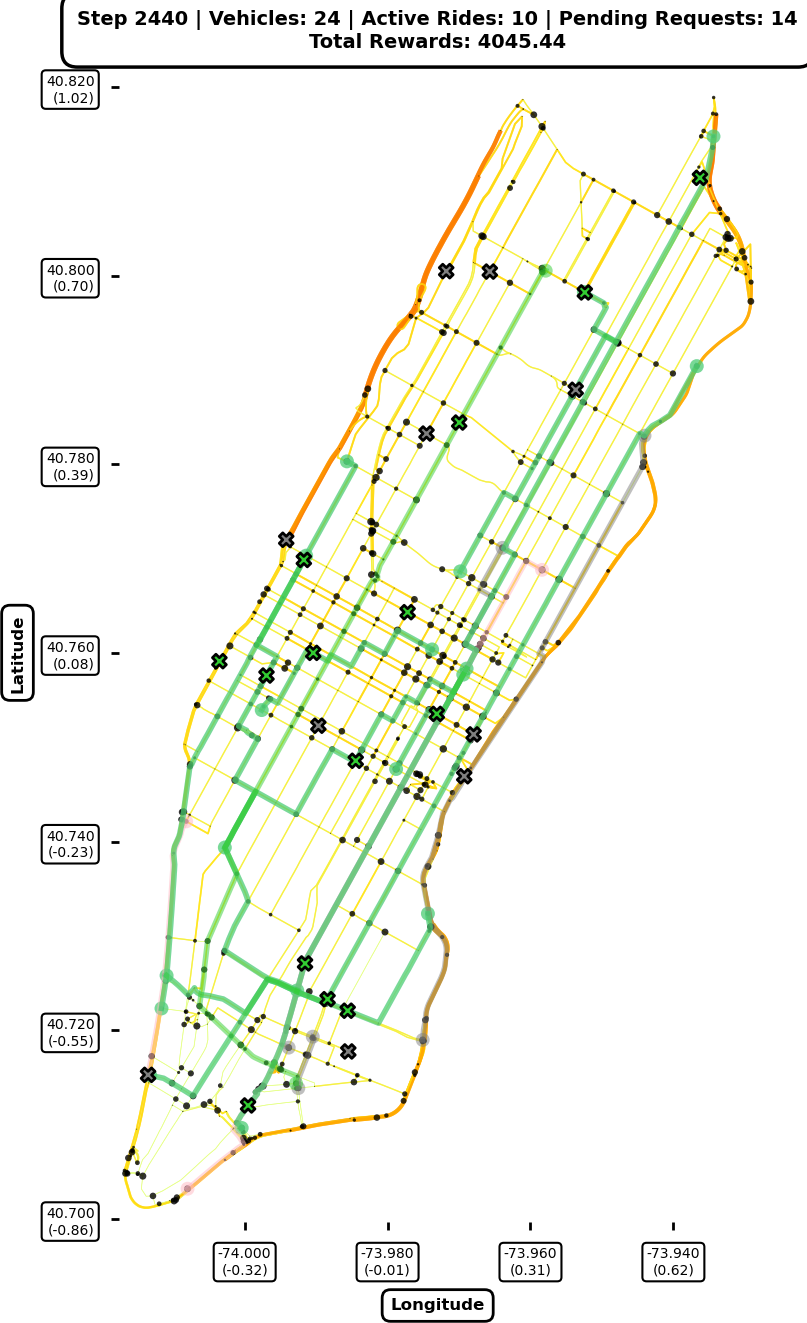

In [13]:
fig, ax = env.render()
fig

<Axes: >

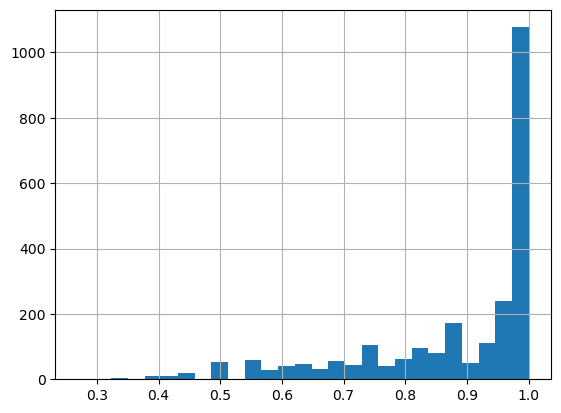

In [14]:
env.breadcrumbs.supply_demand_ratio.hist(bins="rice")

In [15]:
dtt([env.DiscardedRequests])

,request_id,request_dt,cust_id,cust_bias,cust_temperature,est_cost,price,max_wait_time,wait_time,status,pickup_node_id,pickup_x_norm,pickup_y_norm,dropoff_node_id,dropoff_x_norm,dropoff_y_norm,route_nodes,curr_start_node,curr_end_node,route_dist_on_edge,distance_meters,discard_time,discard_step
627,617,2025-01-06 01:36:38.861455,11127,2.731,2.072,4.074,4.120,0 days 00:15:00,0 days 00:12:00,3,11027912161,-0.456,-0.185,370896902,0.085,-0.383,"[11027912161, 42445769, 42445766, 42437914, 42437909, 42435624, 42437890, 42430271, 42437881, 42445867, 4597668041, 42448693, 42446925, 42448701, 42442889, 42448707, 42448714, 42439191, 5137978709, 4161568888, 370896902]",11027912161,42445769.0,0.0,4074.180,2025-01-06 01:48:38.861455,312
1148,1126,2025-01-06 05:01:38.861455,16105,-2.707,2.008,6.602,6.604,0 days 00:15:00,0 days 00:16:00,-2,4207802391,-0.580,-0.785,42435663,-0.159,0.035,"[4207802391, 246923513, 42451375, 42451370, 246911576, 3574648569, 588593059, 4149748671, 42453398, 42429570, 42431626, 42440918, 42424408, 4142105822, 12417264049, 42436374, 42432214, 42435624, 42435644, 42435646, 42435650, 42435663]",4207802391,246923513.0,0.0,6602.053,2025-01-06 05:17:38.861455,521
2604,2628,2025-01-06 16:31:38.861455,4967,-1.575,1.539,1.495,1.522,0 days 00:15:00,0 days 00:01:00,-1,4347534767,0.094,0.150,42435684,-0.101,0.114,"[4347534767, 42430394, 42423674, 4347550074, 1825841693, 1825841743, 1825841704, 42435714, 42435707, 42435705, 42435684]",4347534767,42430394.0,0.0,1494.576,2025-01-06 16:32:38.861455,1196
3370,3387,2025-01-06 22:01:38.861455,1772,-2.475,1.694,8.122,8.214,0 days 00:15:00,0 days 00:01:00,-1,588593353,-0.573,-0.759,42442415,-0.082,0.300,"[588593353, 246909454, 5815234915, 246858435, 246858448, 12410398108, 246889572, 4142073861, 246890579, 246649427, 246649429, 42454328, 246648219, 42445766, 42437914, 42437693, 1701844618, 42437670, 42452975, 42443975, 42455751, 42437371, 42432706, 42455761, 42432598, 42440170, 42449550, 42450434, 42455643, 42442415]",588593353,246909454.0,0.0,8122.463,2025-01-06 22:02:38.861455,1526
4251,4279,2025-01-07 04:34:38.861455,11429,-2.619,2.429,10.828,16.248,0 days 00:15:00,0 days 00:01:00,-1,246923513,-0.576,-0.784,42442534,0.145,0.612,"[246923513, 42451375, 42451370, 246911576, 3574648569, 588593059, 4149748671, 42453398, 42429570, 42431626, 42440918, 9611529611, 42440854, 9607729579, 246649429, 42454328, 246648219, 42445766, 42437914, 42437693, 1701844618, 42437670, 42452975, 42443975, 42455751, 42437371, 42432706, 42455761, 42432598, 42440170, 42449550, 42450434, 42455643, 42442415, 42439464, 9177424867, 1061531491, 6207264908, 42432564, 42442451, 42442463, 42442469, 42442480, 42442534]",246923513,42451375.0,0.0,10827.726,2025-01-07 04:35:38.861455,1919


<Axes: title={'center': 'Discarded Requests by Status'}, xlabel='status'>

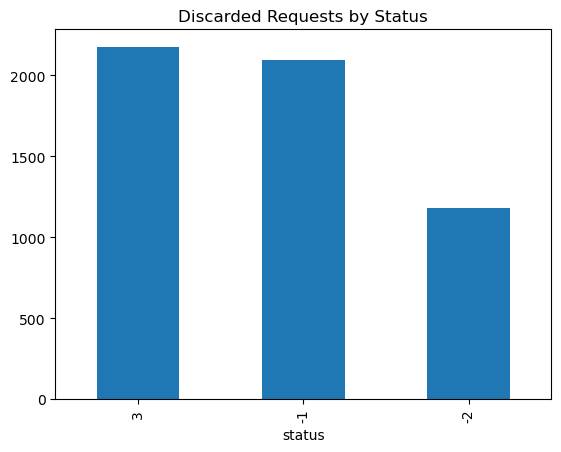

In [16]:
env.DiscardedRequests.status.value_counts().plot(kind="bar", title="Discarded Requests by Status")